Лучшее beta: 0.7
h = 1.1125
LOO-MSE = 0.088236


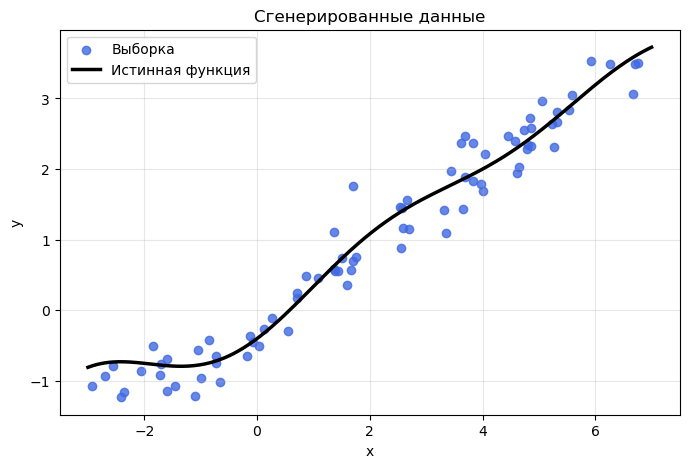

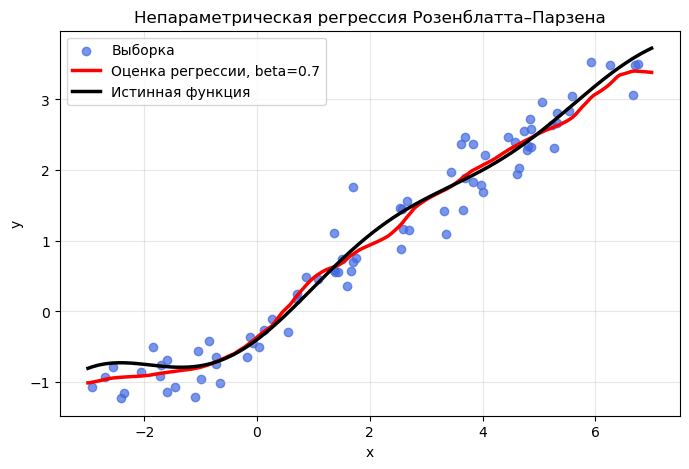

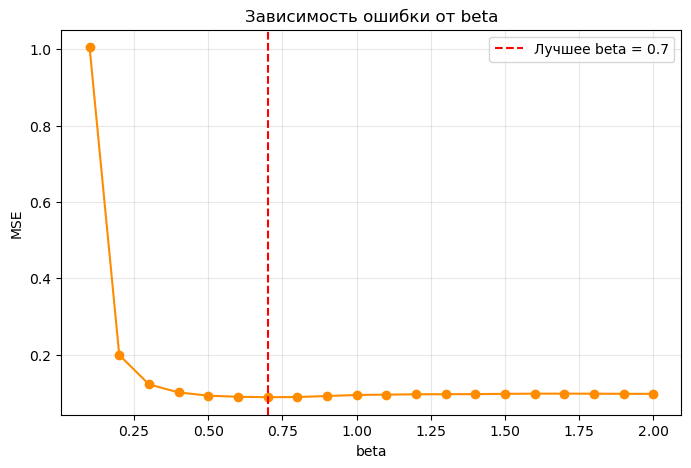

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time


def true_function(x):
    return 0.1 * (x - 4) * np.cos(x) + 0.5 * x


def generate_sample(n=80, x_min=-3, x_max=7, noise_std=0.3, seed=20022026):
    rng = np.random.default_rng(seed)
    x = rng.uniform(x_min, x_max, n)
    y = true_function(x) + rng.normal(0, noise_std, n)
    return x, y


def kernel(z):
    z = np.asarray(z)
    return np.where(np.abs(z) <= 1, 0.75 * (1 - z**2), 0.0)


def compute_delta(x):
    x_sorted = np.sort(x)
    return np.max(np.diff(x_sorted))


def predict_point(x_train, y_train, x0, h):
    weights = kernel((x0 - x_train) / h)
    weight_sum = np.sum(weights)

    if weight_sum == 0:
        return np.mean(y_train)

    return np.sum(weights * y_train) / weight_sum


def predict_curve(x_train, y_train, x_grid, h):
    return np.array([predict_point(x_train, y_train, x0, h) for x0 in x_grid])


def loocv_mse(x, y, beta, delta):
    h = delta / beta
    errors = []

    for i in range(len(x)):
        mask = np.ones(len(x), dtype=bool)
        mask[i] = False

        x_train = x[mask]
        y_train = y[mask]
        y_pred = predict_point(x_train, y_train, x[i], h)

        errors.append((y[i] - y_pred) ** 2)

    return np.mean(errors)


def find_best_beta(x, y, beta_min=0.1, beta_max=2.0, beta_step=0.1):
    delta = compute_delta(x)
    betas = np.arange(beta_min, beta_max + beta_step / 2, beta_step)
    mses = np.array([loocv_mse(x, y, beta, delta) for beta in betas])

    best_index = np.argmin(mses)
    best_beta = betas[best_index]
    best_mse = mses[best_index]

    return best_beta, best_mse, betas, mses, delta


start_time = time.time()

x, y = generate_sample(n=80, seed=42)

best_beta, best_mse, betas, mses, delta = find_best_beta(x, y)
h = delta / best_beta

x_grid = np.linspace(-3, 7, 400)
y_true = true_function(x_grid)
y_pred = predict_curve(x, y, x_grid, h)

elapsed_time = time.time() - start_time

print(f"Лучшее beta: {best_beta:.1f}")
print(f"h = {h:.4f}")
print(f"LOO-MSE = {best_mse:.6f}")
print(f"Время работы: {elapsed_time:.6f} сек.")

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='royalblue', alpha=0.8, label='Выборка')
plt.plot(x_grid, y_true, color='black', linewidth=2.5, label='Истинная функция')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сгенерированные данные')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='royalblue', alpha=0.7, label='Выборка')
plt.plot(x_grid, y_pred, color='red', linewidth=2.5, label=f'Оценка регрессии, beta={best_beta:.1f}')
plt.plot(x_grid, y_true, color='black', linewidth=2.5, label='Истинная функция')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Непараметрическая регрессия Розенблатта–Парзена')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(betas, mses, marker='o', color='darkorange')
plt.axvline(best_beta, color='red', linestyle='--', label=f'Лучшее beta = {best_beta:.1f}')
plt.xlabel('beta')
plt.ylabel('MSE')
plt.title('Зависимость ошибки от beta')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()